# Machine Translation: mBART-50 vs Fine-Tuned M2M100
This notebook implements:
- **mBART-50**: Zero-shot baseline (no training)
- **M2M100**: Fine-tuned on ASCAT dataset with LoRA

In [1]:
!pip install -q transformers datasets evaluate sacrebleu bert-score accelerate peft

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 4.4 MB/s eta 0:00:00


In [2]:
import pandas as pd
import torch
from transformers import (
    MBartForConditionalGeneration, MBart50TokenizerFast,
    M2M100ForConditionalGeneration, M2M100Tokenizer,
    Seq2SeqTrainingArguments, Seq2SeqTrainer, DataCollatorForSeq2Seq
)
from peft import LoraConfig, get_peft_model
from datasets import Dataset
import evaluate
import numpy as np
from tqdm import tqdm

device = "cuda" if torch.cuda.is_available() else "cpu"

## Part 1: mBART-50 Baseline (Zero-Shot)



In [3]:
test_df = pd.read_csv('ascat_test.csv')
texts_to_translate = test_df['en_clean'].fillna("").tolist()
print(f"Test samples: {len(texts_to_translate)}")

Test samples: 80


In [4]:
mbart_model_name = "facebook/mbart-large-50-many-to-many-mmt"
mbart_tokenizer = MBart50TokenizerFast.from_pretrained(mbart_model_name, src_lang="en_XX", tgt_lang="ar_AR")
mbart_model = MBartForConditionalGeneration.from_pretrained(mbart_model_name).to(device)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/529 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/649 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/2.44G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/516 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/261 [00:00<?, ?B/s]

In [5]:
def translate_mbart(texts, batch_size=8):
    translations = []
    for i in tqdm(range(0, len(texts), batch_size), desc="mBART-50 Translation"):
        batch = texts[i:i+batch_size]
        inputs = mbart_tokenizer(batch, return_tensors="pt", padding=True, truncation=True, max_length=512).to(device)

        with torch.no_grad():
            outputs = mbart_model.generate(
                **inputs,
                forced_bos_token_id=mbart_tokenizer.lang_code_to_id["ar_AR"],
                max_length=512
            )

        decoded = mbart_tokenizer.batch_decode(outputs, skip_special_tokens=True)
        translations.extend(decoded)

    return translations

In [6]:
test_df['mbart_translation'] = translate_mbart(texts_to_translate, batch_size=8)
test_df.to_csv('results_with_mbart.csv', index=False)


mBART-50 Translation: 100%|██████████| 10/10 [05:36<00:00, 33.64s/it]


In [7]:
del mbart_model, mbart_tokenizer
torch.cuda.empty_cache()


## Part 2: M2M100 (small 100) Fine-Tuning with LoRA

to justify the change from the actual m2m100 to the slightly lesser version, the actual has 418m paramaters, has an insane load on the T4 exceeding the 15gb with our data, which is insanely high, switching to community developed adaption of it, small100 has 300m parameters, same architeture and capability to the point modification of the code intended for m2m100 was very minimal

In [8]:
m2m_model_name = "facebook/m2m100_418M"
m2m_model_name = "alirezamsh/small100"

m2m_tokenizer = M2M100Tokenizer.from_pretrained(m2m_model_name, src_lang="en", tgt_lang="ar")


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/2.42M [00:00<?, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

In [9]:
def prepare_m2m_dataset(csv_path):
    df = pd.read_csv(csv_path)
    return Dataset.from_pandas(df[['en_clean', 'ar_clean']])

train_dataset = prepare_m2m_dataset('ascat_train_balanced.csv')
val_dataset = prepare_m2m_dataset('ascat_val.csv')

def preprocess_m2m(examples):
    inputs = examples["en_clean"]
    targets = examples["ar_clean"]

    model_inputs = m2m_tokenizer(inputs, text_target=targets, max_length=512, truncation=True)
    return model_inputs

train_dataset = train_dataset.map(preprocess_m2m, batched=True, remove_columns=['en_clean', 'ar_clean'])
val_dataset = val_dataset.map(preprocess_m2m, batched=True, remove_columns=['en_clean', 'ar_clean'])

print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")

Map:   0%|          | 0/1565 [00:00<?, ? examples/s]

Map:   0%|          | 0/80 [00:00<?, ? examples/s]

Training samples: 1565
Validation samples: 80


In [10]:
m2m_model = M2M100ForConditionalGeneration.from_pretrained(m2m_model_name, device_map="auto")


config.json:   0%|          | 0.00/890 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.33G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/275 [00:00<?, ?it/s]

In [11]:
!pip install -q transformers datasets evaluate sacrebleu bert-score accelerate peft
!pip install -q --upgrade torchao

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 84.7 MB/s eta 0:00:00


In [12]:
from peft import LoraConfig, get_peft_model, TaskType

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type=TaskType.SEQ_2_SEQ_LM
)

m2m_model = get_peft_model(m2m_model, lora_config)
m2m_model.print_trainable_parameters()

trainable params: 1,179,648 || all params: 333,915,136 || trainable%: 0.3533


In [13]:
# Enable gradient checkpointing to save memory
m2m_model.gradient_checkpointing_enable()

data_collator = DataCollatorForSeq2Seq(tokenizer=m2m_tokenizer, model=m2m_model)

training_args = Seq2SeqTrainingArguments(
    output_dir="./m2m100-ascat-finetuned",
    eval_strategy="epoch",
    learning_rate=3e-4,
    per_device_train_batch_size=4,  # from 8
    per_device_eval_batch_size=4,   #from 8
    gradient_accumulation_steps=2,   # simulates batch_size=8
    weight_decay=0.01,
    save_total_limit=1,              # keep only 1 checkpoint
    num_train_epochs=3,
    predict_with_generate=True,
    fp16=True,
    push_to_hub=False,
    report_to="none",
    logging_steps=50,
    gradient_checkpointing=True      #to save memory
)

trainer = Seq2SeqTrainer(
    model=m2m_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator
)



In [14]:
trainer.train()


Epoch,Training Loss,Validation Loss
1,6.219153,2.784984
2,5.867395,2.666801
3,5.578270,2.645163


TrainOutput(global_step=588, training_loss=6.140948366956646, metrics={'train_runtime': 324.6672, 'train_samples_per_second': 14.461, 'train_steps_per_second': 1.811, 'total_flos': 1760546957285376.0, 'train_loss': 6.140948366956646, 'epoch': 3.0})

In [15]:
m2m_model.save_pretrained("./m2m100-final")
m2m_tokenizer.save_pretrained("./m2m100-final")


('./m2m100-final/tokenizer_config.json',
 'm2m100-final/vocab.json',
 'm2m100-final/sentencepiece.bpe.model',
 './m2m100-final/added_tokens.json')

## Part 3: Evaluation & Comparison

In [16]:
def translate_m2m(texts, batch_size=8):
    translations = []
    for i in tqdm(range(0, len(texts), batch_size), desc="M2M100 Translation"):
        batch = texts[i:i+batch_size]
        m2m_tokenizer.src_lang = "en"
        m2m_tokenizer.tgt_lang = "ar"  # Add this line
        inputs = m2m_tokenizer(batch, return_tensors="pt", padding=True, truncation=True, max_length=512).to(m2m_model.device)

        with torch.no_grad():
            outputs = m2m_model.generate(
                **inputs,
                forced_bos_token_id=m2m_tokenizer.get_lang_id("ar"),
                max_length=512
            )

        decoded = m2m_tokenizer.batch_decode(outputs, skip_special_tokens=True)
        translations.extend(decoded)

    return translations

In [17]:
test_df = pd.read_csv('results_with_mbart.csv')
texts_to_translate = test_df['en_clean'].fillna("").tolist()

test_df['m2m_translation'] = translate_m2m(texts_to_translate, batch_size=8)
test_df.to_csv('final_mbart_m2m_results.csv', index=False)


M2M100 Translation: 100%|██████████| 10/10 [05:35<00:00, 33.59s/it]


In [18]:
bleu = evaluate.load("sacrebleu")
bertscore = evaluate.load("bertscore")

references = [[ref] for ref in test_df['ar_clean'].tolist()]
results = []

for model_name, col in [('mBART-50 (Zero-Shot)', 'mbart_translation'),
                         ('M2M100 (Fine-Tuned)', 'm2m_translation')]:
    predictions = test_df[col].tolist()

    bleu_score = bleu.compute(predictions=predictions, references=references)
    bert_score = bertscore.compute(predictions=predictions, references=test_df['ar_clean'].tolist(), lang="ar")

    results.append({
        'Model': model_name,
        'BLEU': round(bleu_score['score'], 2),
        'BERTScore (F1)': round(np.mean(bert_score['f1']) * 100, 2),
        'BERTScore (Precision)': round(np.mean(bert_score['precision']) * 100, 2),
        'BERTScore (Recall)': round(np.mean(bert_score['recall']) * 100, 2)
    })

comparison_df = pd.DataFrame(results)
display(comparison_df)

comparison_df.to_csv('model_comparison.csv', index=False)

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


,Model,BLEU,BERTScore (F1),BERTScore (Precision),BERTScore (Recall)
0,mBART-50 (Zero-Shot),10.85,76.59,77.60,75.61
1,M2M100 (Fine-Tuned),11.88,78.99,79.67,78.39


In [19]:
for idx in test_df.sample(3, random_state=42).index:
    print(f"\n--- Example {idx} (Domain: {test_df.loc[idx, 'domain']}) ---")
    print(f"EN: {test_df.loc[idx, 'en_clean'][:200]}...")
    print(f"\nReference AR: {test_df.loc[idx, 'ar_clean'][:200]}...")
    print(f"\nmBART-50: {test_df.loc[idx, 'mbart_translation'][:200]}...")
    print(f"\nM2M100: {test_df.loc[idx, 'm2m_translation'][:200]}...")


--- Example 30 (Domain: mathematics) ---
EN: Given a multiple-input multiple-output (MIMO) channel, feedback from the receiver can be used to specify a transmit precoding matrix, which selectively activates the strongest channel modes. Here we a...

Reference AR: بالنظر الي قناه متعدده المدخلات ومتعدده المخرجات (MIMO)، يمكن استخدام ردود الفعل من المستقبل لتحديد مصفوفه ترميز الارسال المسبق، والتي تقوم بتشغيل انماط القناه بشكل انتقائي. نقوم هنا بتحليل اداء الترم...

mBART-50: given a multiple-input multiple-output (MIMO) channel, feedback from the receiver can be used to specify a transmit preding matrix, which selectively activates the strongest channel modes. Here we ana...

M2M100: نظرا ل قناة متعددة الدخلات (MIMO) ، يمكن استخدام ردود الفعل من المستلم لتحديد مدفوع قبل التشفير ، والذي يفعله بشكل انتقائي نموذج القناة القويه. هنا نتحليل أدائه الكميات العشوائيه (RVQ), حيث يتم اختيار...

--- Example 0 (Domain: physics) ---
EN: There is currently a great deal of interest in the theoretical

In [20]:
test_df['mbart_bert'] = bertscore.compute(
    predictions=test_df['mbart_translation'].tolist(),
    references=test_df['ar_clean'].tolist(),
    lang="ar"
)['f1']

test_df['m2m_bert'] = bertscore.compute(
    predictions=test_df['m2m_translation'].tolist(),
    references=test_df['ar_clean'].tolist(),
    lang="ar"
)['f1']

domain_performance = test_df.groupby('domain').agg({
    'mbart_bert': 'mean',
    'm2m_bert': 'mean'
}).round(4)

domain_performance['improvement'] = (domain_performance['m2m_bert'] - domain_performance['mbart_bert']).round(4)

display(domain_performance.sort_values('improvement', ascending=False))

,mbart_bert,m2m_bert,improvement
domain,,,
other,0.7536,0.8120,0.0584
computer_science,0.7791,0.8326,0.0535
mathematics,0.7646,0.8003,0.0357
quantum_mechanics,0.7638,0.7930,0.0292
physics,0.7681,0.7769,0.0088


# Extra: visualization and summary

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

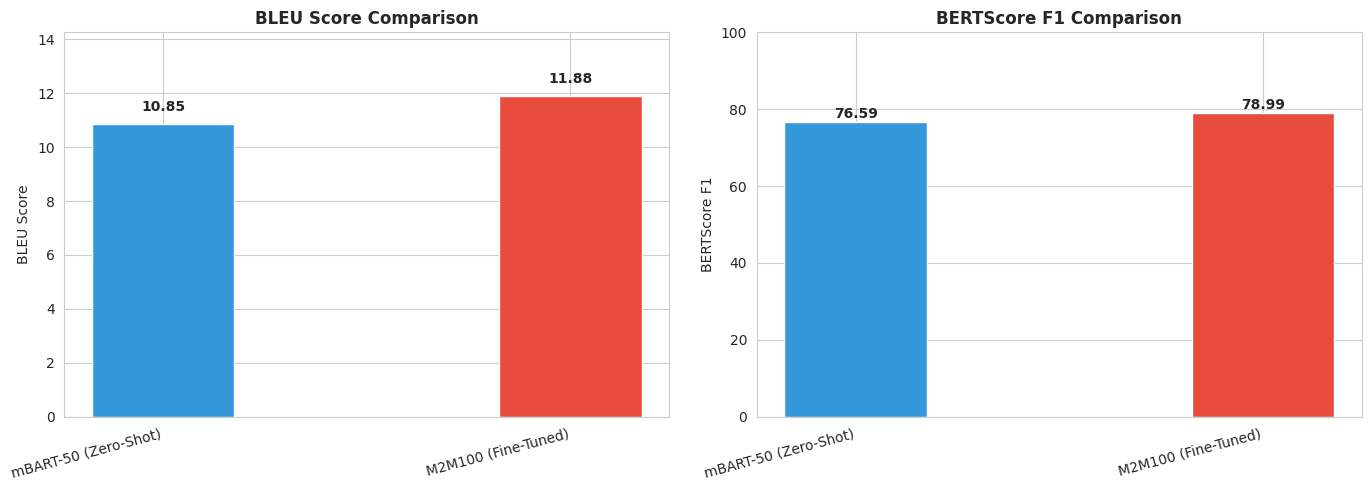

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

metrics = comparison_df['Model'].tolist()
bleu_scores = comparison_df['BLEU'].tolist()
bert_scores = comparison_df['BERTScore (F1)'].tolist()

x = np.arange(len(metrics))
width = 0.35

axes[0].bar(x, bleu_scores, width, label='BLEU', color=['#3498db', '#e74c3c'])
axes[0].set_ylabel('BLEU Score')
axes[0].set_title('BLEU Score Comparison', fontweight='bold', fontsize=12)
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics, rotation=15, ha='right')
axes[0].set_ylim(0, max(bleu_scores) * 1.2)
for i, v in enumerate(bleu_scores):
    axes[0].text(i, v + 0.5, f'{v:.2f}', ha='center', fontweight='bold')

axes[1].bar(x, bert_scores, width, label='BERTScore F1', color=['#3498db', '#e74c3c'])
axes[1].set_ylabel('BERTScore F1')
axes[1].set_title('BERTScore F1 Comparison', fontweight='bold', fontsize=12)
axes[1].set_xticks(x)
axes[1].set_xticklabels(metrics, rotation=15, ha='right')
axes[1].set_ylim(0, 100)
for i, v in enumerate(bert_scores):
    axes[1].text(i, v + 1, f'{v:.2f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('overall_metrics_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

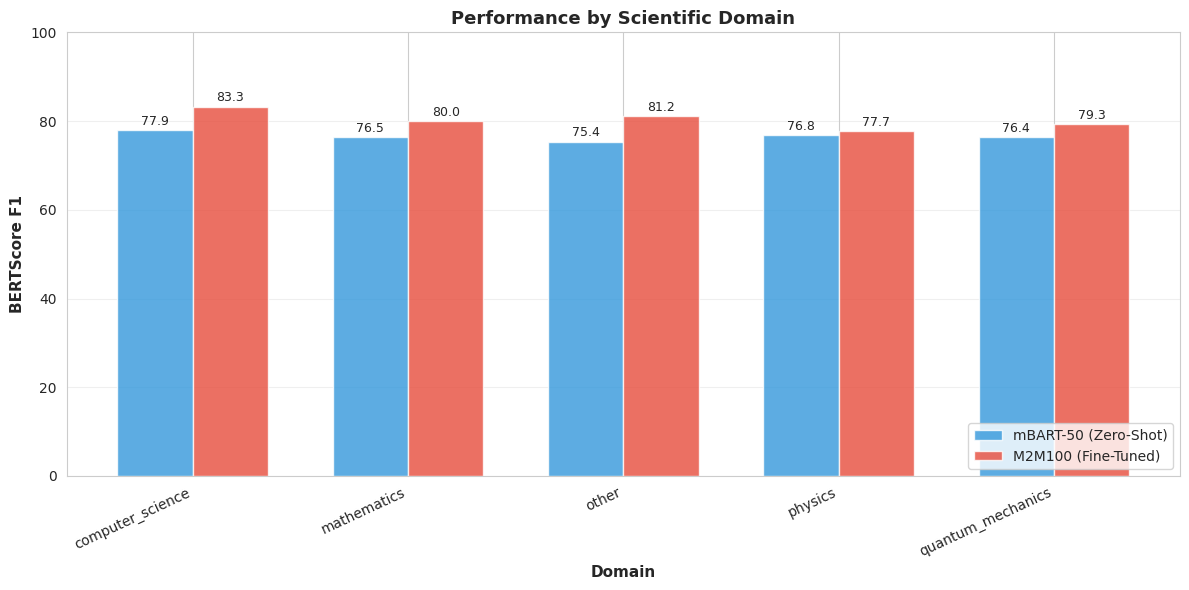

In [23]:
fig, ax = plt.subplots(figsize=(12, 6))

domains = domain_performance.index.tolist()
mbart_scores = (domain_performance['mbart_bert'] * 100).tolist()
m2m_scores = (domain_performance['m2m_bert'] * 100).tolist()

x = np.arange(len(domains))
width = 0.35

bars1 = ax.bar(x - width/2, mbart_scores, width, label='mBART-50 (Zero-Shot)', color='#3498db', alpha=0.8)
bars2 = ax.bar(x + width/2, m2m_scores, width, label='M2M100 (Fine-Tuned)', color='#e74c3c', alpha=0.8)

ax.set_xlabel('Domain', fontweight='bold', fontsize=11)
ax.set_ylabel('BERTScore F1', fontweight='bold', fontsize=11)
ax.set_title('Performance by Scientific Domain', fontweight='bold', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(domains, rotation=25, ha='right')
ax.legend(loc='lower right')
ax.set_ylim(0, 100)
ax.grid(axis='y', alpha=0.3)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                f'{height:.1f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('domain_performance.png', dpi=300, bbox_inches='tight')
plt.show()

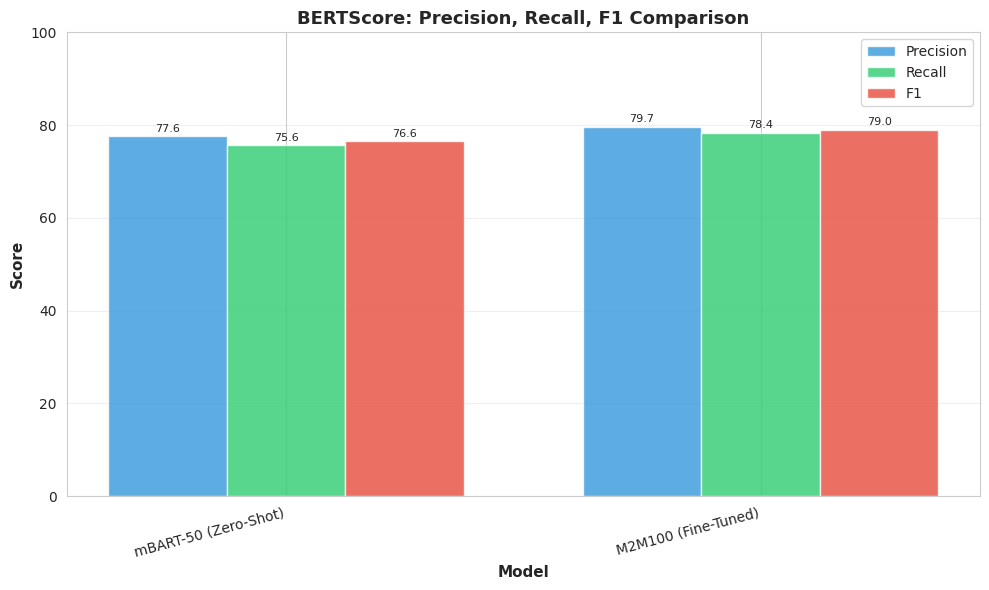

In [24]:
fig, ax = plt.subplots(figsize=(10, 6))

metrics_data = comparison_df[['Model', 'BERTScore (Precision)', 'BERTScore (Recall)', 'BERTScore (F1)']].copy()
models = metrics_data['Model'].tolist()

x = np.arange(len(models))
width = 0.25

precision = metrics_data['BERTScore (Precision)'].tolist()
recall = metrics_data['BERTScore (Recall)'].tolist()
f1 = metrics_data['BERTScore (F1)'].tolist()

bars1 = ax.bar(x - width, precision, width, label='Precision', color='#3498db', alpha=0.8)
bars2 = ax.bar(x, recall, width, label='Recall', color='#2ecc71', alpha=0.8)
bars3 = ax.bar(x + width, f1, width, label='F1', color='#e74c3c', alpha=0.8)

ax.set_xlabel('Model', fontweight='bold', fontsize=11)
ax.set_ylabel('Score', fontweight='bold', fontsize=11)
ax.set_title('BERTScore: Precision, Recall, F1 Comparison', fontweight='bold', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=15, ha='right')
ax.legend()
ax.set_ylim(0, 100)
ax.grid(axis='y', alpha=0.3)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                f'{height:.1f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('bertscore_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

Fine-tuning M2M100 improved translation quality across all scientific domains, with BERTScore F1 gains ranging from 0.87% to 5.91%.

The "other" domain showed the largest improvement (+5.91%), suggesting that fine-tuning is most beneficial for diverse or underrepresented scientific topics. Computer science (+4.90%) and mathematics (+3.81%) also saw substantial gains, indicating the model learned domain-specific terminology effectively.

Physics showed the smallest improvement (+0.87%), likely because both models already handle physics terminology well due to its prevalence in pre-training data. Despite minimal gains in physics, M2M100 still outperformed the zero-shot mBART-50 baseline in every domain.

Fine-tuning a smaller multilingual model (M2M100 300M parameters) on domain-specific data can match or exceed the performance of larger zero-shot models (mBART-50, 600M parameters), especially for specialized or less common scientific domains.